[nltk_data] Downloading package stopwords to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


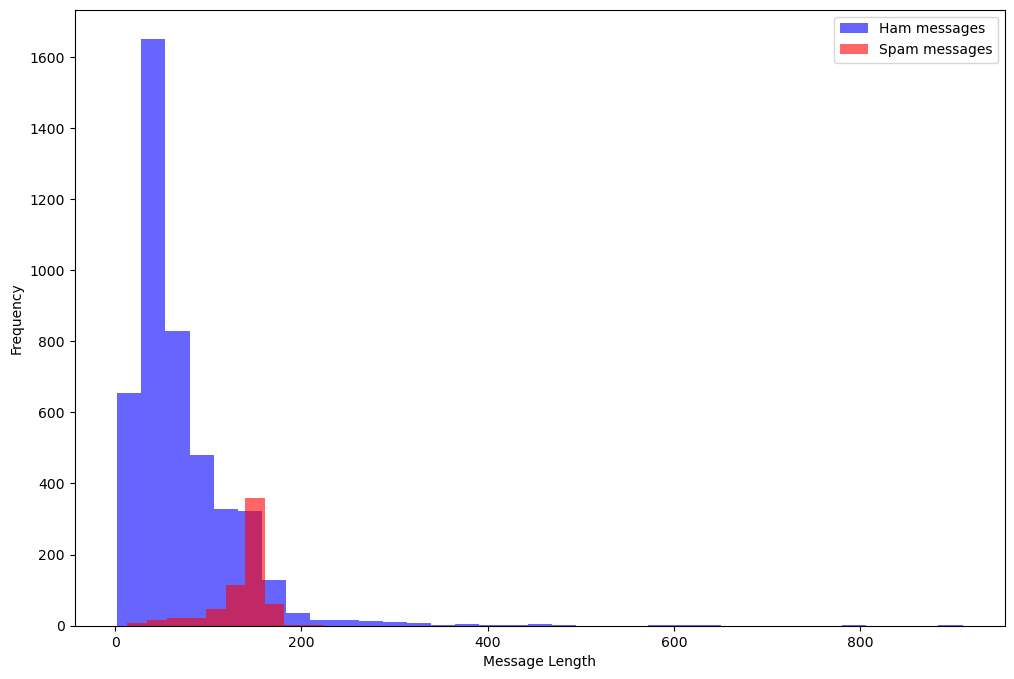

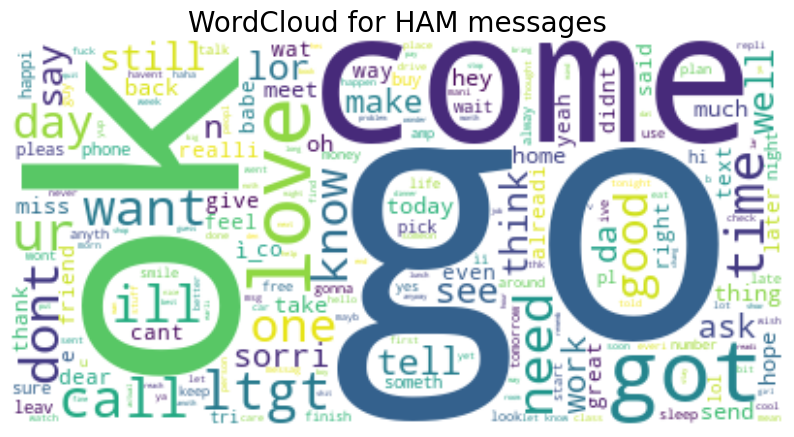

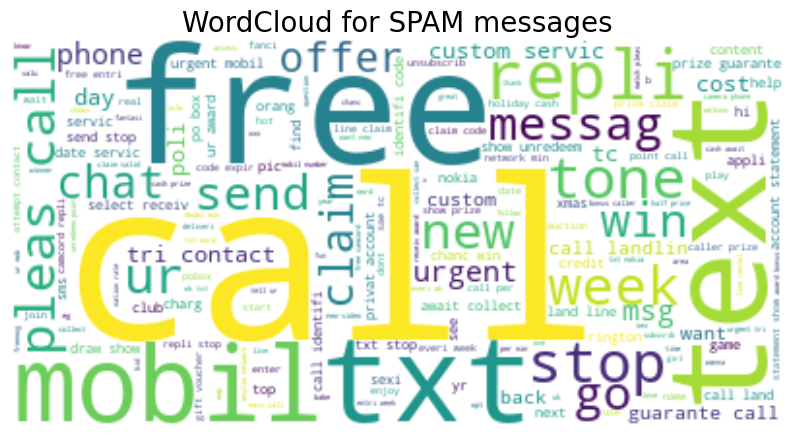

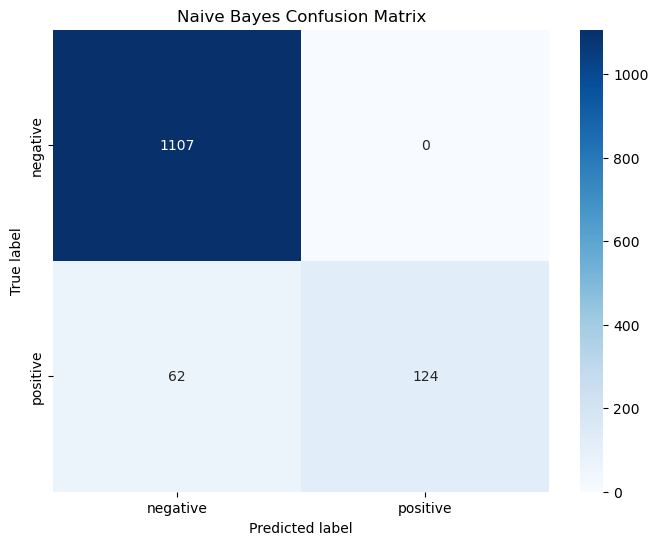

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1107
        spam       1.00      0.67      0.80       186

    accuracy                           0.95      1293
   macro avg       0.97      0.83      0.89      1293
weighted avg       0.95      0.95      0.95      1293


Naive Bayes Error Rate: 0.05


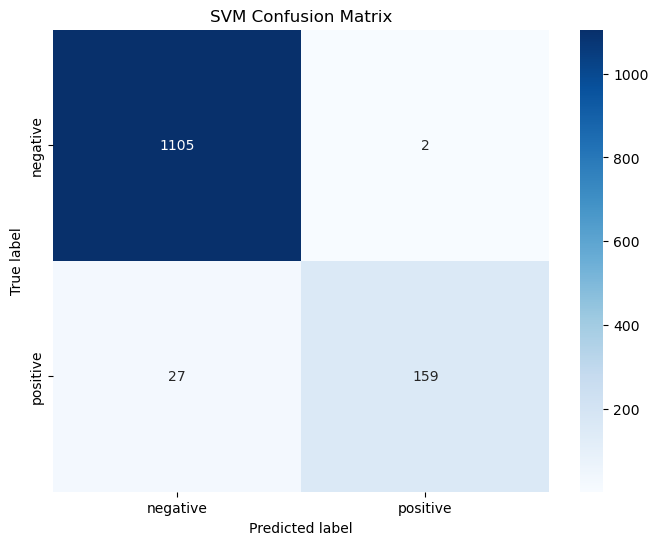


SVM Classifier Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1107
        spam       0.99      0.85      0.92       186

    accuracy                           0.98      1293
   macro avg       0.98      0.93      0.95      1293
weighted avg       0.98      0.98      0.98      1293


SVM Error Rate: 0.02


In [1]:
# ── ALL IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_csv("smsspamcollection.csv", encoding="ISO-8859-1")
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.columns = ['label', 'message']

# ── EDA ───────────────────────────────────────────────────────────────────────
df['label_num'] = df.label.map({'ham':0, 'spam':1})
df['message_len'] = df.message.apply(len)

plt.figure(figsize=(12, 8))
df[df.label=='ham'].message_len.plot(bins=35, kind='hist', color='blue', label='Ham messages', alpha=0.6)
df[df.label=='spam'].message_len.plot(kind='hist', color='red', label='Spam messages', alpha=0.6)
plt.legend()
plt.xlabel("Message Length")
plt.show()

# ── PREPROCESSING ─────────────────────────────────────────────────────────────
stop_words = stopwords.words('english') + ['u', 'im', 'c']
stemmer = nltk.SnowballStemmer("english")

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'http\S+\s*\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text

df['message_clean'] = df['message'].apply(preprocess)

# ── WORDCLOUD HAM ─────────────────────────────────────────────────────────────
wc = WordCloud(background_color='white', max_words=200, contour_color='steelblue', contour_width=2)
ham_text = ' '.join(text for text in df.loc[df['label'] == 'ham', 'message_clean'])
wc.generate(ham_text)
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('WordCloud for HAM messages', fontsize=20)
plt.axis('off')
plt.show()

# ── WORDCLOUD SPAM ────────────────────────────────────────────────────────────
wc = WordCloud(background_color='white', max_words=200, contour_color='steelblue', contour_width=2)
spam_text = ' '.join(text for text in df.loc[df['label'] == 'spam', 'message_clean'])
wc.generate(spam_text)
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('WordCloud for SPAM messages', fontsize=20)
plt.axis('off')
plt.show()

# ── VECTORIZATION ─────────────────────────────────────────────────────────────
tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(df['message_clean'])
y = df['label']

# ── MODELING ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
nb_clf = MultinomialNB().fit(X_train, y_train)
svm_clf = SVC(kernel='linear').fit(X_train, y_train)

# ── EVALUATION ────────────────────────────────────────────────────────────────
nb_predicted = nb_clf.predict(X_test)
nb_report = classification_report(y_test, nb_predicted)
nb_error_rate = 1 - accuracy_score(y_test, nb_predicted)
nb_cm = confusion_matrix(y_test, nb_predicted)

svm_predicted = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_predicted)
svm_error_rate = 1 - accuracy_score(y_test, svm_predicted)
svm_cm = confusion_matrix(y_test, svm_predicted)

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

plot_confusion_matrix(nb_cm, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report)
print(f"\nNaive Bayes Error Rate: {nb_error_rate:.2f}")

plot_confusion_matrix(svm_cm, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report)
print(f"\nSVM Error Rate: {svm_error_rate:.2f}")

In [2]:
# ── EXERCISE ──────────────────────────────────────────────────────────────────
df2 = pd.read_csv("Processed_Reviews.csv")
df2 = df2.drop_duplicates()

labels = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
df2['label'] = labels

df2 = df2[['lemmatized', 'label']].dropna()

tfidf_vect2 = TfidfVectorizer()
X2 = tfidf_vect2.fit_transform(df2['lemmatized'])
y2 = df2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)
nb_clf2 = MultinomialNB().fit(X2_train, y2_train)
svm_clf2 = SVC(kernel='linear').fit(X2_train, y2_train)

nb_predicted2 = nb_clf2.predict(X2_test)
nb_report2 = classification_report(y2_test, nb_predicted2, zero_division=0)
nb_error_rate2 = 1 - accuracy_score(y2_test, nb_predicted2)
nb_cm2 = confusion_matrix(y2_test, nb_predicted2)

svm_predicted2 = svm_clf2.predict(X2_test)
svm_report2 = classification_report(y2_test, svm_predicted2, zero_division=0)
svm_error_rate2 = 1 - accuracy_score(y2_test, svm_predicted2)
svm_cm2 = confusion_matrix(y2_test, svm_predicted2)

plot_confusion_matrix(nb_cm2, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report2)
print(f"\nNaive Bayes Error Rate: {nb_error_rate2:.2f}")

plot_confusion_matrix(svm_cm2, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report2)
print(f"\nSVM Error Rate: {svm_error_rate2:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'Processed_Reviews.csv'

In [3]:
# ── EXERCISE ──────────────────────────────────────────────────────────────────
df2 = pd.read_csv("Processed_Reviews.csv")
df2 = df2.drop_duplicates()

labels = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
df2['label'] = labels

df2 = df2[['lemmatized', 'label']].dropna()

tfidf_vect2 = TfidfVectorizer()
X2 = tfidf_vect2.fit_transform(df2['lemmatized'])
y2 = df2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)
nb_clf2 = MultinomialNB().fit(X2_train, y2_train)
svm_clf2 = SVC(kernel='linear').fit(X2_train, y2_train)

nb_predicted2 = nb_clf2.predict(X2_test)
nb_report2 = classification_report(y2_test, nb_predicted2, zero_division=0)
nb_error_rate2 = 1 - accuracy_score(y2_test, nb_predicted2)
nb_cm2 = confusion_matrix(y2_test, nb_predicted2)

svm_predicted2 = svm_clf2.predict(X2_test)
svm_report2 = classification_report(y2_test, svm_predicted2, zero_division=0)
svm_error_rate2 = 1 - accuracy_score(y2_test, svm_predicted2)
svm_cm2 = confusion_matrix(y2_test, svm_predicted2)

plot_confusion_matrix(nb_cm2, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report2)
print(f"\nNaive Bayes Error Rate: {nb_error_rate2:.2f}")

plot_confusion_matrix(svm_cm2, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report2)
print(f"\nSVM Error Rate: {svm_error_rate2:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'Processed_Reviews.csv'

In [1]:
# ── EXERCISE ──────────────────────────────────────────────────────────────────
df2 = pd.read_csv("Processed_Reviews.csv")
df2 = df2.drop_duplicates()

labels = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
df2['label'] = labels

df2 = df2[['lemmatized', 'label']].dropna()

tfidf_vect2 = TfidfVectorizer()
X2 = tfidf_vect2.fit_transform(df2['lemmatized'])
y2 = df2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)
nb_clf2 = MultinomialNB().fit(X2_train, y2_train)
svm_clf2 = SVC(kernel='linear').fit(X2_train, y2_train)

nb_predicted2 = nb_clf2.predict(X2_test)
nb_report2 = classification_report(y2_test, nb_predicted2, zero_division=0)
nb_error_rate2 = 1 - accuracy_score(y2_test, nb_predicted2)
nb_cm2 = confusion_matrix(y2_test, nb_predicted2)

svm_predicted2 = svm_clf2.predict(X2_test)
svm_report2 = classification_report(y2_test, svm_predicted2, zero_division=0)
svm_error_rate2 = 1 - accuracy_score(y2_test, svm_predicted2)
svm_cm2 = confusion_matrix(y2_test, svm_predicted2)

plot_confusion_matrix(nb_cm2, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report2)
print(f"\nNaive Bayes Error Rate: {nb_error_rate2:.2f}")

plot_confusion_matrix(svm_cm2, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report2)
print(f"\nSVM Error Rate: {svm_error_rate2:.2f}")

NameError: name 'pd' is not defined

In [2]:
# ── EXERCISE ──────────────────────────────────────────────────────────────────
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv("Processed_Reviews.csv")
df2 = df2.drop_duplicates()

labels = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
df2['label'] = labels

df2 = df2[['lemmatized', 'label']].dropna()

tfidf_vect2 = TfidfVectorizer()
X2 = tfidf_vect2.fit_transform(df2['lemmatized'])
y2 = df2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)
nb_clf2 = MultinomialNB().fit(X2_train, y2_train)
svm_clf2 = SVC(kernel='linear').fit(X2_train, y2_train)

nb_predicted2 = nb_clf2.predict(X2_test)
nb_report2 = classification_report(y2_test, nb_predicted2, zero_division=0)
nb_error_rate2 = 1 - accuracy_score(y2_test, nb_predicted2)
nb_cm2 = confusion_matrix(y2_test, nb_predicted2)

svm_predicted2 = svm_clf2.predict(X2_test)
svm_report2 = classification_report(y2_test, svm_predicted2, zero_division=0)
svm_error_rate2 = 1 - accuracy_score(y2_test, svm_predicted2)
svm_cm2 = confusion_matrix(y2_test, svm_predicted2)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

plot_confusion_matrix(nb_cm2, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report2)
print(f"\nNaive Bayes Error Rate: {nb_error_rate2:.2f}")

plot_confusion_matrix(svm_cm2, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report2)
print(f"\nSVM Error Rate: {svm_error_rate2:.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'Processed_Reviews.csv'

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


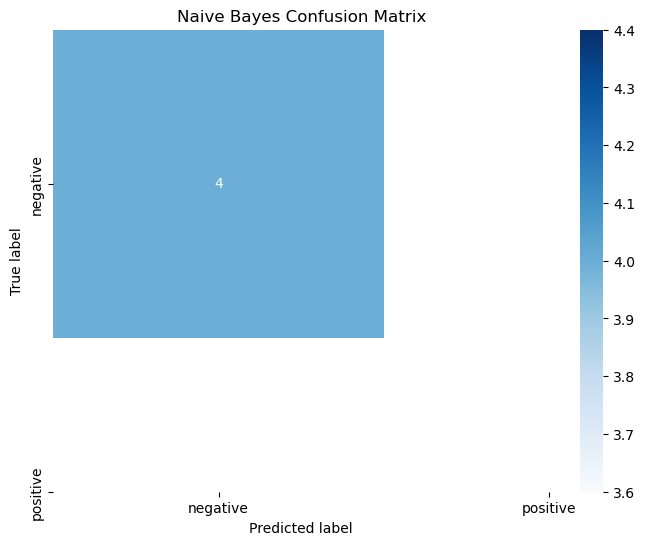

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Naive Bayes Error Rate: 0.00


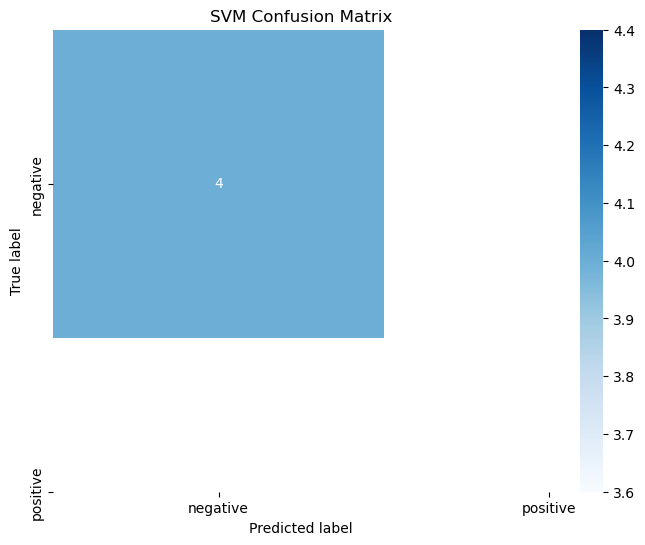


SVM Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


SVM Error Rate: 0.00


In [1]:
# ── EXERCISE ──────────────────────────────────────────────────────────────────
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv("Processed_Reviews.csv")
df2 = df2.drop_duplicates()

labels = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
df2['label'] = labels

df2 = df2[['lemmatized', 'label']].dropna()

tfidf_vect2 = TfidfVectorizer()
X2 = tfidf_vect2.fit_transform(df2['lemmatized'])
y2 = df2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)
nb_clf2 = MultinomialNB().fit(X2_train, y2_train)
svm_clf2 = SVC(kernel='linear').fit(X2_train, y2_train)

nb_predicted2 = nb_clf2.predict(X2_test)
nb_report2 = classification_report(y2_test, nb_predicted2, zero_division=0)
nb_error_rate2 = 1 - accuracy_score(y2_test, nb_predicted2)
nb_cm2 = confusion_matrix(y2_test, nb_predicted2)

svm_predicted2 = svm_clf2.predict(X2_test)
svm_report2 = classification_report(y2_test, svm_predicted2, zero_division=0)
svm_error_rate2 = 1 - accuracy_score(y2_test, svm_predicted2)
svm_cm2 = confusion_matrix(y2_test, svm_predicted2)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

plot_confusion_matrix(nb_cm2, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report2)
print(f"\nNaive Bayes Error Rate: {nb_error_rate2:.2f}")

plot_confusion_matrix(svm_cm2, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report2)
print(f"\nSVM Error Rate: {svm_error_rate2:.2f}")